In [140]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,classification_report,
    confusion_matrix)

In [114]:
bank = pd.read_csv('Bank+marketing/data/bank/bank.csv', sep=';')
bankfull = pd.read_csv('Bank+marketing/data/bank/bank-full.csv', sep=';')

In [115]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [116]:
bankfull.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [117]:
bank.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [118]:
bankfull.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [119]:
bank.shape

(4521, 17)

In [83]:
bankfull.shape

(45211, 17)

In [84]:
bankfull.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [120]:
categorical_cols = bankfull.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    unique_count = bankfull[col].nunique()
    print(f"Column: {col}, Unique Value Count: {unique_count}")

Column: job, Unique Value Count: 12
Column: marital, Unique Value Count: 3
Column: education, Unique Value Count: 4
Column: default, Unique Value Count: 2
Column: housing, Unique Value Count: 2
Column: loan, Unique Value Count: 2
Column: contact, Unique Value Count: 3
Column: month, Unique Value Count: 12
Column: poutcome, Unique Value Count: 4
Column: y, Unique Value Count: 2


/var/folders/4y/g2kyr2gx0918zbyp0y8rqj6w0000gn/T/ipykernel_82315/3925537551.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = bankfull.select_dtypes(include=['object', 'category']).columns


In [121]:
print(bankfull["y"].value_counts(normalize=True).round(4))

y
no     0.883
yes    0.117
Name: proportion, dtype: float64


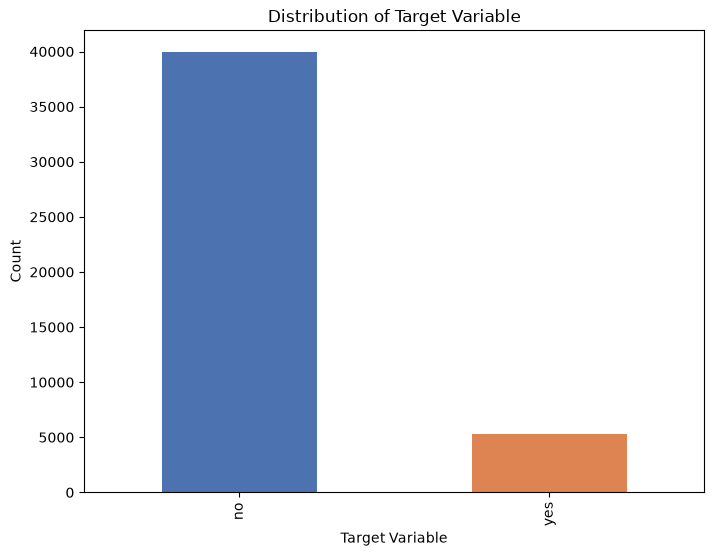

In [122]:
plt.figure(figsize=(8, 6))
ax = plt.gca()
bankfull["y"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
plt.title('Distribution of Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()

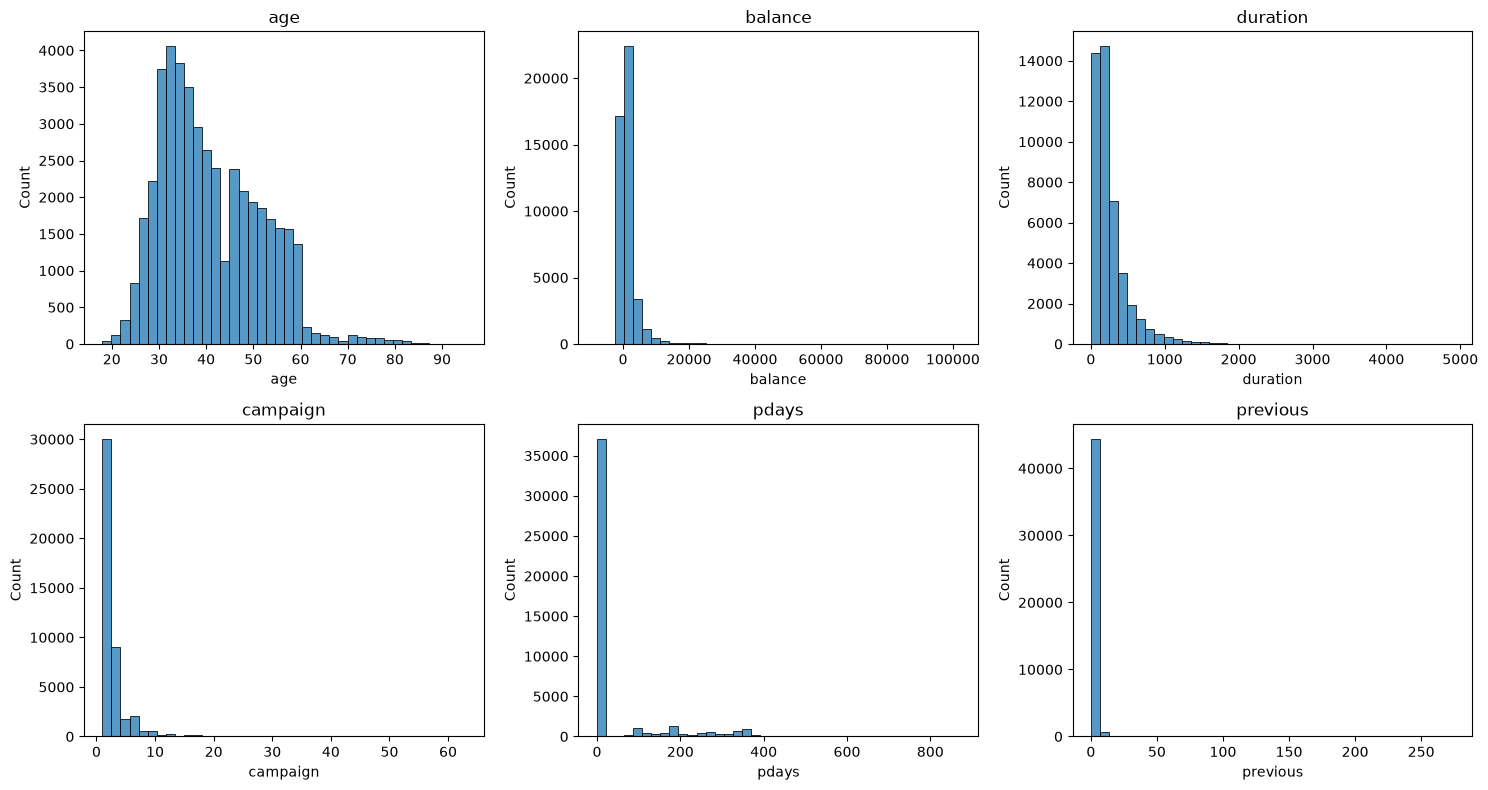

In [88]:
numeric_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(bankfull[col], bins=40, ax=ax, kde=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

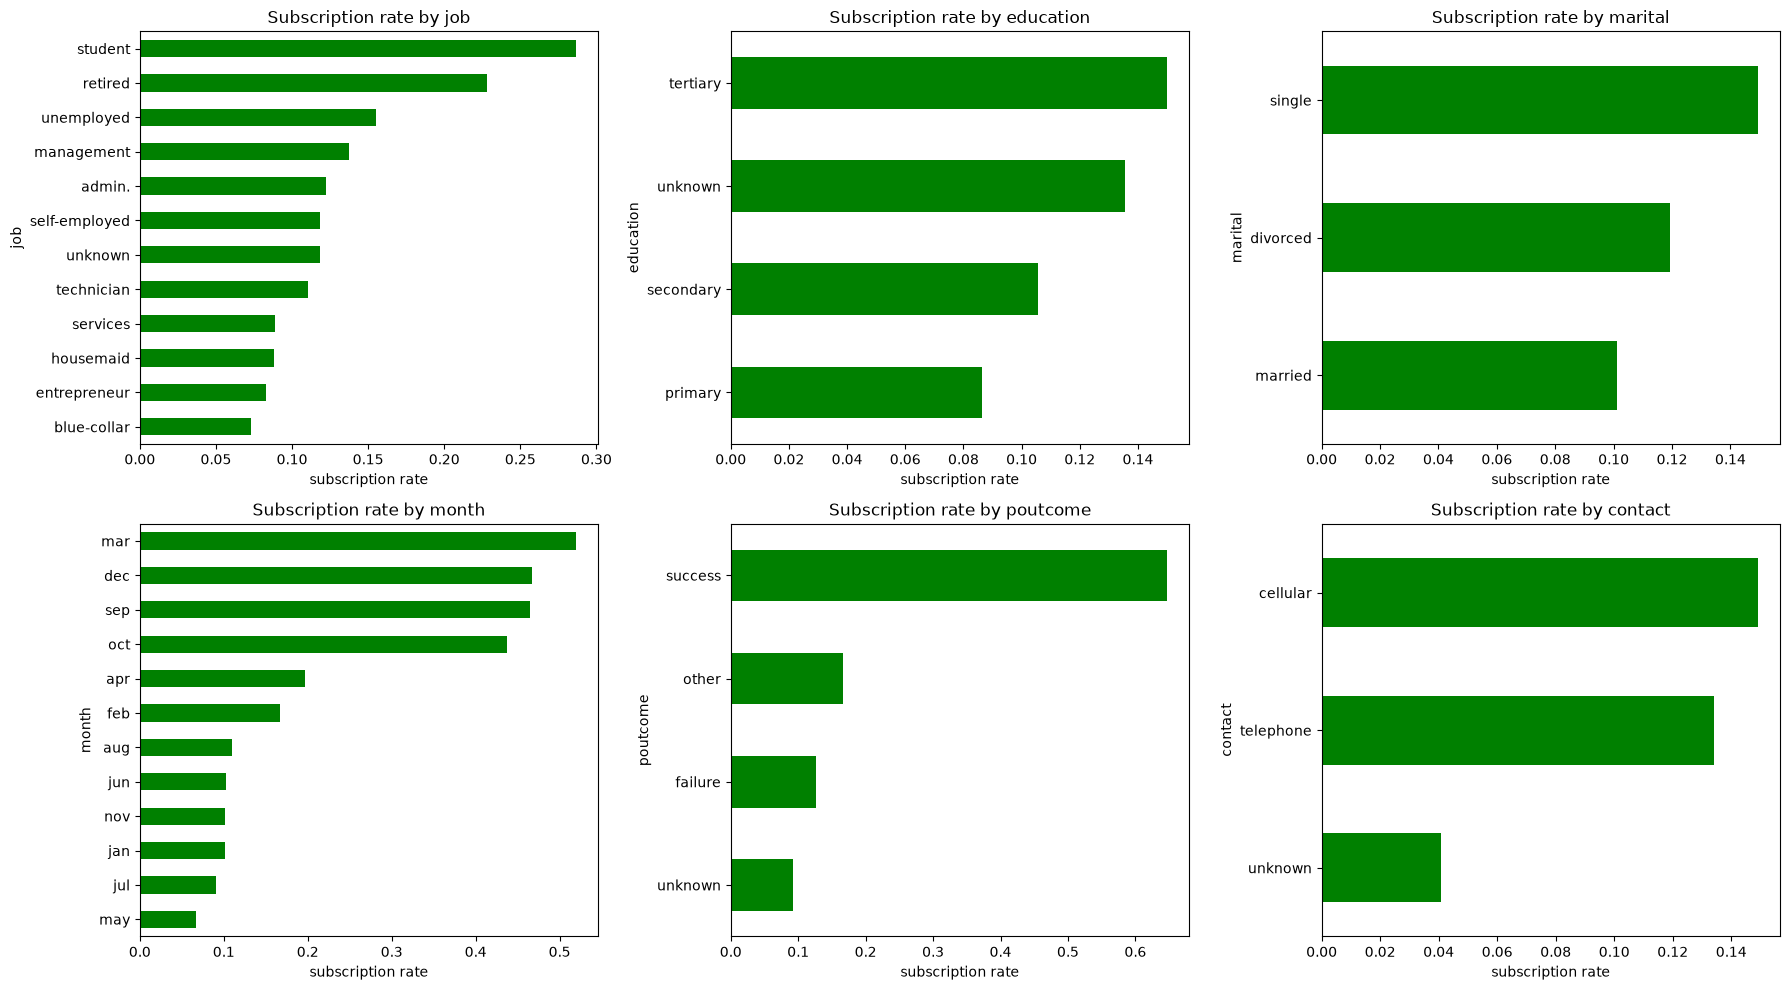

In [89]:
cat_cols = ["job", "education", "marital", "month", "poutcome", "contact"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, cat_cols):
    rate = bankfull.groupby(col)["y"].apply(lambda s: (s == "yes").mean()).sort_values()
    rate.plot(kind="barh", ax=ax, color="Green")
    ax.set_title(f"Subscription rate by {col}")
    ax.set_xlabel("subscription rate")
plt.tight_layout()
plt.show()

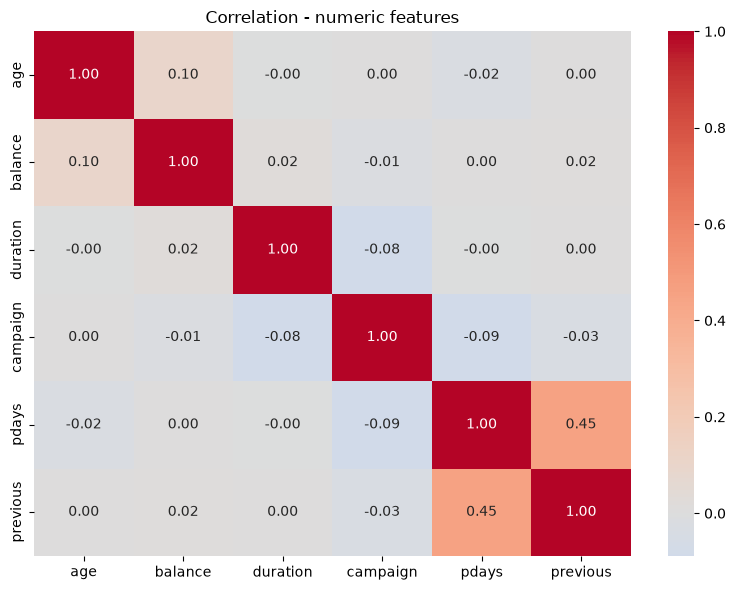

In [90]:
plt.figure(figsize=(8, 6))
corr = bankfull[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",center=0)
plt.title("Correlation - numeric features")
plt.tight_layout()
plt.show()

In [91]:
bankfull.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [123]:
CATEGORICAL_COLS = [
    "job", "marital", "education", "default", "housing",
    "loan", "contact", "month", "poutcome",
]

NUMERIC_COLS = [
    "age", "balance", "day", "duration", "campaign",
    "pdays", "previous",
]


In [124]:
numeric_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoding",OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("num",numeric_transformer,NUMERIC_COLS),
    ("categorical",categorical_transformer,CATEGORICAL_COLS)
])

model = Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("classfication",RandomForestClassifier(n_estimators=100,random_state=42))
])

In [129]:
X = bankfull.drop(columns = ['y'])
y = bankfull['y']

In [130]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify = y
)
print("Train: ",X_train.shape[0],"| Test: ",X_test.shape[0])

Train:  36168 | Test:  9043


In [131]:
X_train

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
26646,31,admin.,married,secondary,no,782,yes,no,cellular,20,nov,427,1,-1,0,unknown
25126,55,services,married,secondary,no,3546,yes,yes,cellular,18,nov,588,1,110,2,failure
39182,36,technician,single,secondary,no,23,yes,no,cellular,18,may,69,2,333,2,failure
40682,34,admin.,married,tertiary,no,35,yes,no,cellular,7,aug,88,2,-1,0,unknown
25189,47,admin.,single,secondary,no,2540,no,no,cellular,18,nov,110,5,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24160,34,admin.,married,tertiary,no,899,yes,no,unknown,12,nov,114,1,170,3,failure
10105,39,blue-collar,single,secondary,no,393,yes,no,unknown,11,jun,339,1,-1,0,unknown
2670,23,blue-collar,married,primary,no,-213,no,no,unknown,13,may,165,2,-1,0,unknown
4684,38,services,married,secondary,no,173,yes,no,unknown,20,may,130,2,-1,0,unknown


In [132]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classfication', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

In [135]:
y_pred = model.predict(X_test)

print("Accuracy score: ",round(accuracy_score(y_test,y_pred)*100,2),"%")
print("Classification Report : \n",classification_report(y_test,y_pred,target_names=['<=50K','>50K']))
print("Confusion matris: \n",confusion_matrix(y_test,y_pred))

Accuracy score:  90.18 %
Classification Report : 
               precision    recall  f1-score   support

       <=50K       0.92      0.97      0.95      7985
        >50K       0.63      0.38      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.68      0.71      9043
weighted avg       0.89      0.90      0.89      9043

Confusion matris: 
 [[7754  231]
 [ 657  401]]


In [138]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scores = cross_val_score(model,X,y,cv = cv,scoring='accuracy')
print("Scores for 5 fold: ",scores.round(3))
print("Mean CV score: ",scores.mean().round(3))

Scores for 5 fold:  [0.907 0.903 0.906 0.91  0.906]
Mean CV score:  0.906


In [141]:
joblib.dump(model,"model/bank_marketing_model.joblib")
print("Saved")

Saved


In [142]:
loaded_model = joblib.load("model/bank_marketing_model.joblib")

In [143]:
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classfication', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

In [144]:
bankfull.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object